In [6]:
import pandas as pd

In [7]:
customers = pd.read_csv("/Users/tanveer/Downloads/customers.csv")
transactions = pd.read_csv("/Users/tanveer/Downloads/transactions.csv")

In [8]:
customers.head()

,id,name,age,country
0,1,Alice,25,UK
1,2,Bob,30,UK
2,3,Charlie,35,USA
3,4,David,28,Canada
4,5,Emma,32,UK


In [9]:
transactions.head()

,id,customer_id,amount,transaction_date
0,1,1,200,2026-01-05
1,2,2,500,2026-01-10
2,3,1,300,2026-02-15
3,4,3,150,2026-02-20
4,5,4,100,2026-03-01


In [10]:
df = pd.merge(customers, transactions, left_on="id", right_on="customer_id")
df.head()

,id_x,name,age,country,id_y,customer_id,amount,transaction_date
0,1,Alice,25,UK,1,1,200,2026-01-05
1,1,Alice,25,UK,3,1,300,2026-02-15
2,1,Alice,25,UK,11,1,350,2026-03-25
3,2,Bob,30,UK,2,2,500,2026-01-10
4,2,Bob,30,UK,6,2,400,2026-03-05


In [11]:
summary = df.groupby(["name", "country"]).agg(
    total_transactions=("id_y", "count"),
    total_spent=("amount", "sum"),
    avg_transaction=("amount", "mean")
).reset_index()

summary

,name,country,total_transactions,total_spent,avg_transaction
0,Alice,UK,3,850,283.333333
1,Bob,UK,3,1350,450.000000
2,Charlie,USA,1,150,150.000000
3,David,Canada,1,100,100.000000
4,Emma,UK,1,250,250.000000
5,Frank,USA,1,120,120.000000
6,Grace,UK,1,600,600.000000
7,Henry,Canada,1,180,180.000000


In [12]:
def segment(x):
    if x >= 1000:
        return "High Value"
    elif x >= 500:
        return "Medium Value"
    else:
        return "Low Value"

summary["customer_segment"] = summary["total_spent"].apply(segment)

<Axes: xlabel='customer_segment'>

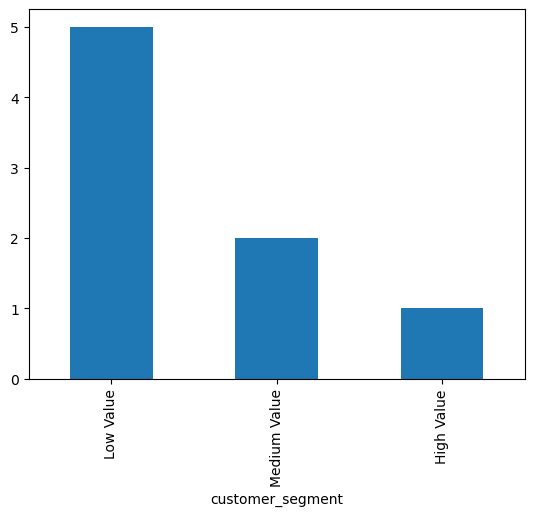

In [13]:
summary["customer_segment"].value_counts().plot(kind="bar")

<Axes: xlabel='customer_segment'>

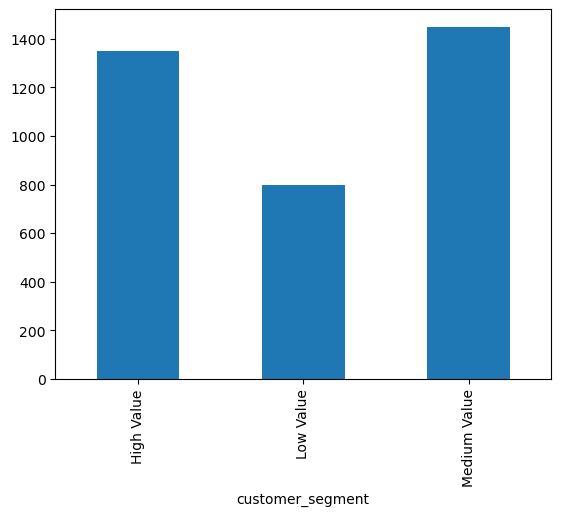

In [16]:
summary.groupby("customer_segment")["total_spent"].sum().plot(kind="bar")

<Axes: xlabel='country'>

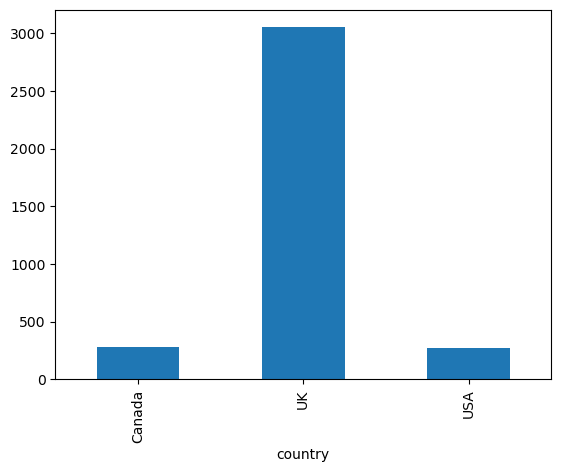

In [15]:
summary.groupby("country")["total_spent"].sum().plot(kind="bar")

In [ ]:
#Insights

Customer Distribution:The majority of customers fall into the low-value segment (5 out of 8), with only one high-value customer. This indicates that while the business has a broad customer base, most customers contribute relatively small amounts of revenue.
    
Revenue Concentration:Despite being the smallest group, high-value and medium-value customers contribute the majority of total revenue. In particular, medium-value customers collectively generate the highest revenue, showing that mid-tier customers are crucial to business performance.
    
Geographic Performance:The UK dominates total revenue by a significant margin, contributing the vast majority compared to the USA and Canada. This suggests a strong domestic market but highlights a lack of international revenue diversification.
    
Customer Behaviour:Bob is the highest-value customer, spending £1350 across multiple transactions, while Alice also contributes significantly with consistent spending. This suggests that repeat customers drive a large portion of revenue.
    
Growth Oppurtunity:The large number of low-value customers presents an opportunity for the business to increase revenue through targeted strategies such as promotions, upselling, or customer retention programs.